In [ ]:
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
import os
import h5py
import kagglehub
import numpy as np
import webdataset as wds
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Alberta Wells Dataset/ValSet.h5'

def explore_h5(name, obj):
    """Función para imprimir la estructura del archivo"""
    indent = '  ' * name.count('/')
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Grupo: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")

with h5py.File(file_path, 'r') as f:
    print(f"Estructura de: {file_path}\n")
    f.visititems(explore_h5)

In [ ]:
# Definición de rutas y constantes del dataset
FILE_PATH = '/content/drive/MyDrive/Alberta Wells Dataset/ValSet.h5'  # Ajustar a la ruta local del entorno
SAMPLE_ID = '5016'
IMG_KEY = f'image/eval_{SAMPLE_ID}'
MASK_KEY = f'label/multi_class_seg_maps/eval_{SAMPLE_ID}'

with h5py.File(FILE_PATH, 'r') as f:
    # Extracción de tensores desde disco a RAM
    # Estructura esperada: (Canales, Altura, Anchura) -> (4, 412, 412)
    full_img = f[IMG_KEY][:]
    mask = f[MASK_KEY][:]

# Separación de componentes espectrales
# Los índices 0, 1, 2 corresponden a Red, Green, Blue respectivamente
rgb_img = full_img[0:3, :, :]
# El índice 3 corresponde al Near-Infrared (NIR)
nir_channel = full_img[3, :, :]

# Reordenamiento de ejes para compatibilidad con Matplotlib (C, H, W) -> (H, W, C)
rgb_display = np.transpose(rgb_img, (1, 2, 0))

# Normalización opcional para visualización si el tipo es uint16
if rgb_display.max() > 255:
    rgb_display = (rgb_display / rgb_display.max() * 255).astype(np.uint8)

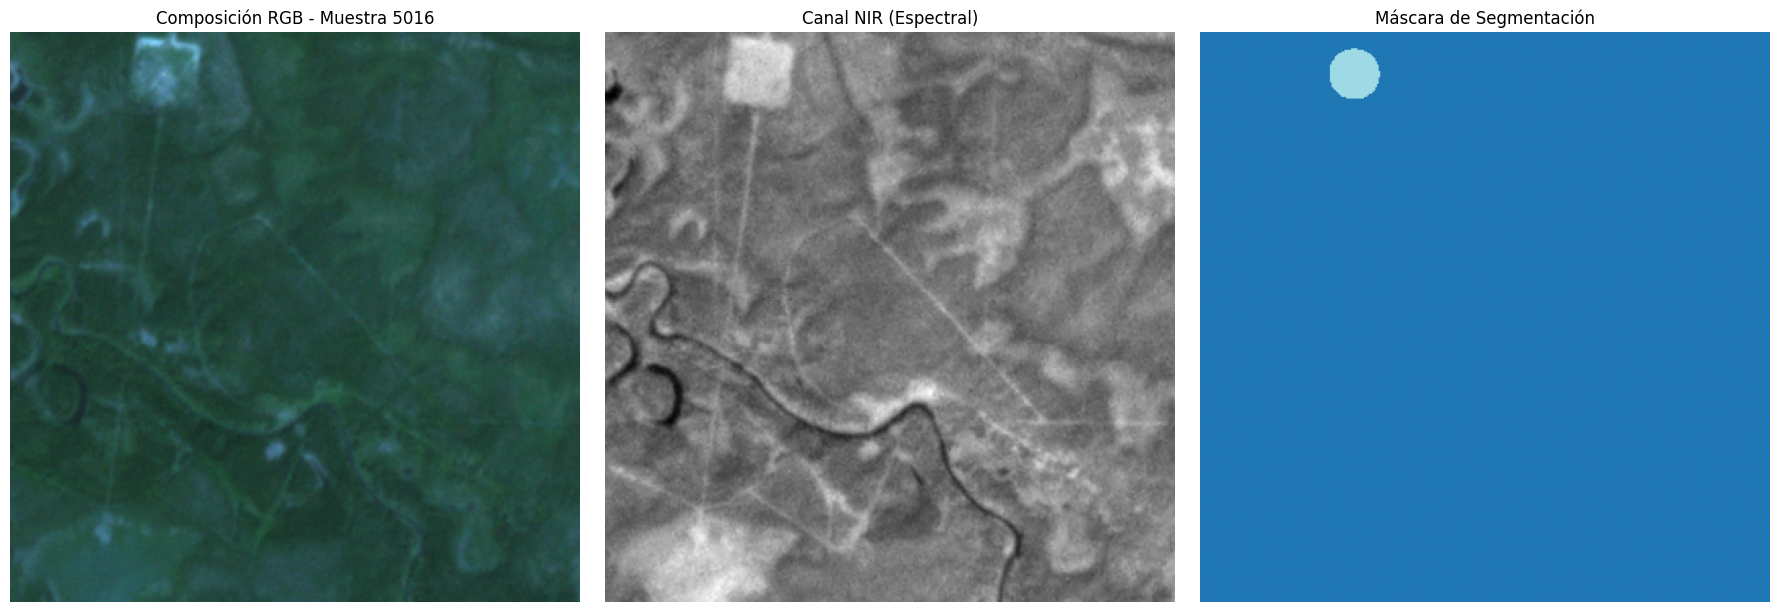

In [ ]:
# Configuración del entorno de visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Composición Color Verdadero (RGB)
axes[0].imshow(rgb_display)
axes[0].set_title(f'Composición RGB - Muestra {SAMPLE_ID}')
axes[0].axis('off')

# Subplot 2: Infrarrojo Cercano (NIR)
axes[1].imshow(nir_channel, cmap='gray')
axes[1].set_title('Canal NIR (Espectral)')
axes[1].axis('off')

# Subplot 3: Mapa de Segmentación (Ground Truth)
# Se utiliza 'tab20' o 'jet' para diferenciar clases discretas
axes[2].imshow(mask, cmap='tab20')
axes[2].set_title('Máscara de Segmentación')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
H5_PATH = '/content/drive/MyDrive/Alberta Wells Dataset/ValSet.h5'
OUTPUT_DIR = '/content'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_shard(ids, h5_file, output_filename):
    """Escribe una lista de IDs específica en un archivo .tar"""
    with wds.TarWriter(output_filename) as sink:
        for idx in ids:
            # Extracción de datos desde el H5
            img = h5_file[f'image/eval_{idx}'][:]
            mask = h5_file[f'label/multi_class_seg_maps/eval_{idx}'][:]

            # Escritura en el shard
            sink.write({
                "__key__": f"sample_{idx}",
                "rgb_nir.npy": img.astype(np.uint16),
                "mask.npy": mask.astype(np.uint16)
            })

with h5py.File(H5_PATH, 'r') as f:
    # 1. Obtener y limpiar todos los IDs disponibles
    all_ids = [k.split('_')[1] for k in f['image'].keys()]

    # 2. Split: 70% Train, 30% Resto (para luego dividir en Val y Test)
    train_ids, temp_ids = train_test_split(all_ids, train_size=0.7, random_state=42)
    val_ids, test_ids = train_test_split(temp_ids, train_size=0.5, random_state=42)

    print(f"Split final: Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

    # 3. Generar los archivos .tar
    print("Serializando Train...")
    save_shard(train_ids, f, os.path.join(OUTPUT_DIR, 'train.tar'))

    print("Serializando Validation...")
    save_shard(val_ids, f, os.path.join(OUTPUT_DIR, 'val.tar'))

    print("Serializando Test...")
    save_shard(test_ids, f, os.path.join(OUTPUT_DIR, 'test.tar'))

print("Proceso completado.")

Split final: Train: 6624 | Val: 1419 | Test: 1420
Serializando Train...
Serializando Validation...
Serializando Test...
Proceso completado.


In [ ]:
# Genera tus .tar como siempre, pero cámbiales el nombre
!mv train.tar train.bin
!mv val.tar val.bin
!mv test.tar test.bin

# Luego empaqueta estos .bin en un .zip para subirlos
!zip dataset.zip train.bin val.bin test.bin

  adding: train.bin (deflated 57%)
  adding: val.bin (deflated 57%)
  adding: test.bin (deflated 56%)


In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
handle = ("lucasiturriago/albertawells")
local_dataset_dir = "/content/dataset.zip"
kagglehub.dataset_upload(handle, local_dataset_dir)

Uploading Dataset https://api.kaggle.com/datasets/lucasiturriago/albertawells ...
Starting upload for file /content/dataset.zip


Uploading: 100%|██████████| 6.01G/6.01G [00:51<00:00, 116MB/s]

Upload successful: /content/dataset.zip (6GB)


Your dataset has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/lucasiturriago/albertawells
